# Notebook 1 — EDA & Preprocessing
**RSNA Pneumonia Detection Challenge**

Prepares and saves all preprocessed images + split CSVs for training.

### Pipeline order
1. Load CSVs
2. Filter missing DICOM files **before** any EDA or splitting
3. EDA (class distribution, bbox analysis, sample images, shape check, pixel stats)
4. Binary labels + class weights
5. Bounding box map
6. Stratified 70 / 15 / 15 split on `patientId`
7. Preprocess & save `_full.npy` for every patient + `_roi.npy` for positives
8. Save splits, labels, and class-balanced XAI examples

## 0 — Install Dependencies by running it on terminal

In [2]:
# Activate your environment first
#D:\XAI_project\tf_gpu\Scripts\activate

# Then install
#pip install -r requirements.txt

## 1 — Imports

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pydicom
import cv2

from tqdm import tqdm
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

## 2 — Paths

In [4]:
data_dir      = r"D:\XAI_project\Data"
processed_dir = r"D:\XAI_project\processed"


image_dir = os.path.join(data_dir, "stage_2_train_images")
os.makedirs(processed_dir, exist_ok=True)
print("Directories ready.")
print(f"  data_dir      : {data_dir}")
print(f"  image_dir     : {image_dir}")
print(f"  processed_dir : {processed_dir}")

Directories ready.
  data_dir      : D:\XAI_project\Data
  image_dir     : D:\XAI_project\Data\stage_2_train_images
  processed_dir : D:\XAI_project\processed


## 3 — Load CSVs

In [5]:
labels     = pd.read_csv(os.path.join(data_dir, "stage_2_train_labels.csv"))
class_info = pd.read_csv(os.path.join(data_dir, "stage_2_detailed_class_info.csv"))

print("Labels shape     :", labels.shape)
print("Class info shape :", class_info.shape)
print("\nLabels columns   :", labels.columns.tolist())
print("Class info cols  :", class_info.columns.tolist())
print("\nFirst 3 rows of class_info:")
class_info.head(3)

Labels shape     : (30227, 6)
Class info shape : (30227, 2)

Labels columns   : ['patientId', 'x', 'y', 'width', 'height', 'Target']
Class info cols  : ['patientId', 'class']

First 3 rows of class_info:


,patientId,class
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,No Lung Opacity / Not Normal
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,No Lung Opacity / Not Normal
2,00322d4d-1c29-4943-afc9-b6754be640eb,No Lung Opacity / Not Normal


## 4 — Filter Missing DICOM Files

> **Why first:** Filtering before EDA and splitting ensures all counts,
> percentages, and split sizes reflect only patients we can actually use.
> Filtering after the split would let broken IDs silently enter train/val/test.

In [6]:
valid_ids = [
    pid for pid in tqdm(class_info["patientId"].unique(), desc="Checking DICOMs")
    if os.path.exists(os.path.join(image_dir, pid + ".dcm"))
]

n_before   = len(class_info)
class_info = class_info[class_info["patientId"].isin(valid_ids)].reset_index(drop=True)
n_after    = len(class_info)

print(f"\nPatients before filter : {n_before}")
print(f"Patients after  filter : {n_after}")
print(f"Removed (missing DCM)  : {n_before - n_after}")

Checking DICOMs: 100%|██████████| 26684/26684 [00:02<00:00, 12135.05it/s]


Patients before filter : 30227
Patients after  filter : 30227
Removed (missing DCM)  : 0


## 5 — EDA: Class Distribution

C:\Users\ahmed\AppData\Local\Temp\ipykernel_4272\521414457.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=class_counts.index, y=class_counts.values, palette="Blues_d")


Class counts:
class
No Lung Opacity / Not Normal    11821
Lung Opacity                     9555
Normal                           8851
Name: count, dtype: int64

Class percentages:
class
No Lung Opacity / Not Normal    39.11
Lung Opacity                    31.61
Normal                          29.28
Name: count, dtype: float64


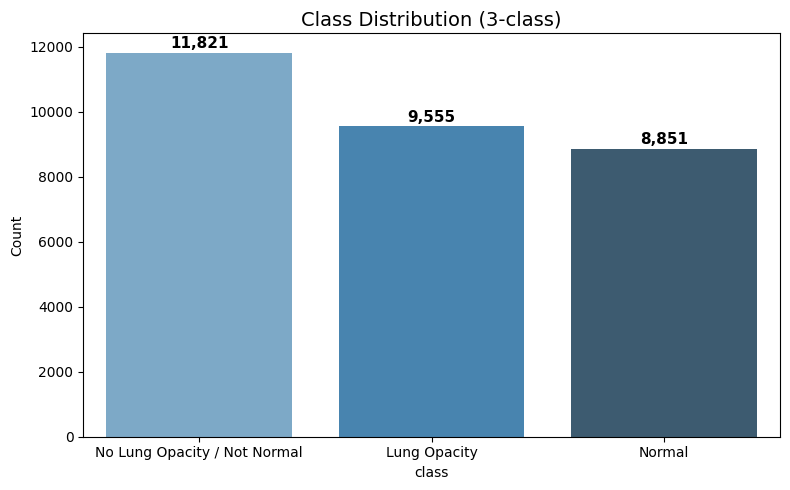

In [7]:
class_counts = class_info["class"].value_counts()

print("Class counts:")
print(class_counts)
print("\nClass percentages:")
print((class_counts / len(class_info) * 100).round(2))

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=class_counts.index, y=class_counts.values, palette="Blues_d")
for bar, val in zip(ax.patches, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f"{val:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")
plt.title("Class Distribution (3-class)", fontsize=14)
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(processed_dir, "eda_class_distribution.png"), dpi=150)
plt.show()

## 6 — EDA: Duplicate Patient Check

In [ ]:
duplicates = class_info["patientId"].duplicated().sum()
print(f"Duplicate patient rows in class_info: {duplicates}")

if duplicates > 0:
    print(class_info[class_info["patientId"].duplicated(keep=False)])
else:
    print(" No duplicates found.")

Duplicate patient rows in class_info: 3543
                                  patientId         class
4      00436515-870c-4b36-a041-de91049b9ab4  Lung Opacity
5      00436515-870c-4b36-a041-de91049b9ab4  Lung Opacity
8      00704310-78a8-4b38-8475-49f4573b2dbb  Lung Opacity
9      00704310-78a8-4b38-8475-49f4573b2dbb  Lung Opacity
14     00aecb01-a116-45a2-956c-08d2fa55433f  Lung Opacity
...                                     ...           ...
30220  c1e73a4e-7afe-4ec5-8af6-ce8315d7a2f2  Lung Opacity
30221  c1ec14ff-f6d7-4b38-b0cb-fe07041cbdc8  Lung Opacity
30222  c1ec14ff-f6d7-4b38-b0cb-fe07041cbdc8  Lung Opacity
30225  c1f7889a-9ea9-4acb-b64c-b737c929599a  Lung Opacity
30226  c1f7889a-9ea9-4acb-b64c-b737c929599a  Lung Opacity

[6941 rows x 2 columns]


## 7 — EDA: Bounding Box Analysis

Total bounding box rows : 9555
Unique positive patients: 6012

Sample rows:
                               patientId      x      y  width  height  Target
4   00436515-870c-4b36-a041-de91049b9ab4  264.0  152.0  213.0   379.0       1
5   00436515-870c-4b36-a041-de91049b9ab4  562.0  152.0  256.0   453.0       1
8   00704310-78a8-4b38-8475-49f4573b2dbb  323.0  577.0  160.0   104.0       1
9   00704310-78a8-4b38-8475-49f4573b2dbb  695.0  575.0  162.0   137.0       1
14  00aecb01-a116-45a2-956c-08d2fa55433f  288.0  322.0   94.0   135.0       1

Boxes per patient:
2    3266
1    2614
3     119
4      13

Describe:
count    6012.000000
mean        1.589321
std         0.542800
min         1.000000
25%         1.000000
50%         2.000000
75%         2.000000
max         4.000000
dtype: float64


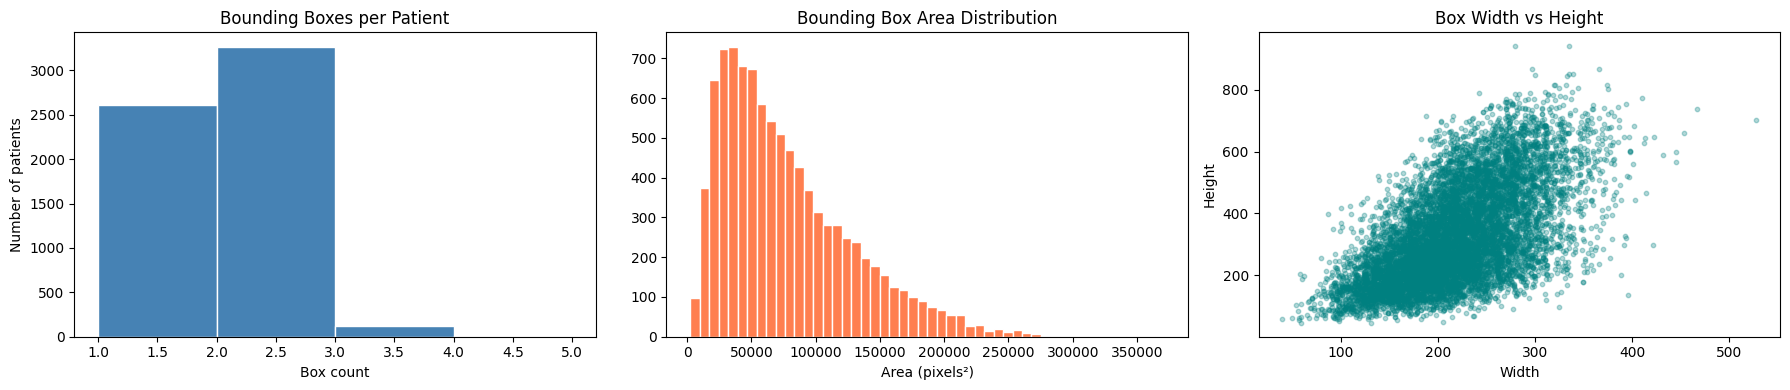

In [ ]:
pneumonia_boxes = labels[labels["Target"] == 1]
print(f"Total bounding box rows : {len(pneumonia_boxes)}")
print(f"Unique positive patients: {pneumonia_boxes['patientId'].nunique()}")
print("\nSample rows:")
print(pneumonia_boxes.head())

boxes_per_patient = pneumonia_boxes.groupby("patientId").size()
print("\nBoxes per patient:")
print(boxes_per_patient.value_counts().to_string())
print("\nDescribe:")
print(boxes_per_patient.describe())

box_area = pneumonia_boxes["width"] * pneumonia_boxes["height"]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(boxes_per_patient, bins=range(1, boxes_per_patient.max() + 2),
             color="steelblue", edgecolor="white")
axes[0].set_title("Bounding Boxes per Patient")
axes[0].set_xlabel("Box count")
axes[0].set_ylabel("Number of patients")

axes[1].hist(box_area, bins=50, color="coral", edgecolor="white")
axes[1].set_title("Bounding Box Area Distribution")
axes[1].set_xlabel("Area of (pixels)")

axes[2].scatter(pneumonia_boxes["width"], pneumonia_boxes["height"],
                alpha=0.3, s=10, color="teal")
axes[2].set_title("Box Width vs Height")
axes[2].set_xlabel("Width")
axes[2].set_ylabel("Height")

plt.tight_layout()
plt.savefig(os.path.join(processed_dir, "eda_bbox_analysis.png"), dpi=150)
plt.show()

## 8 — EDA: Sample Images Per Class

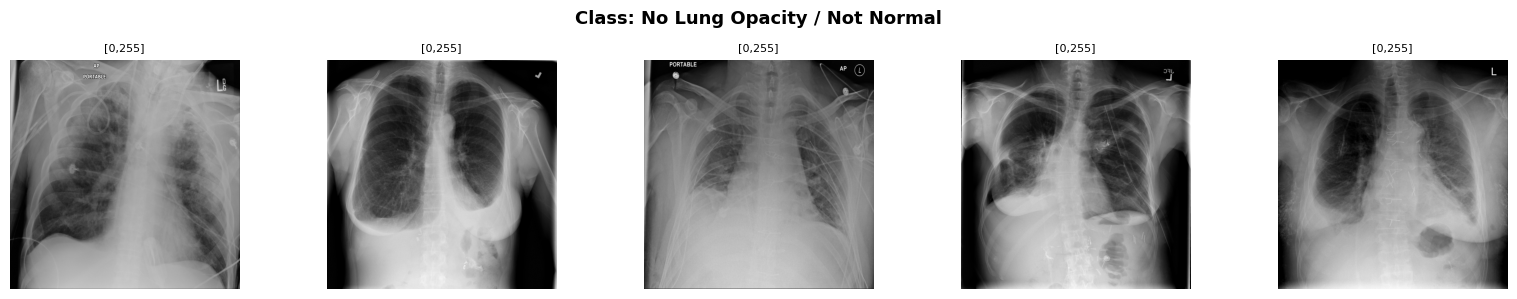

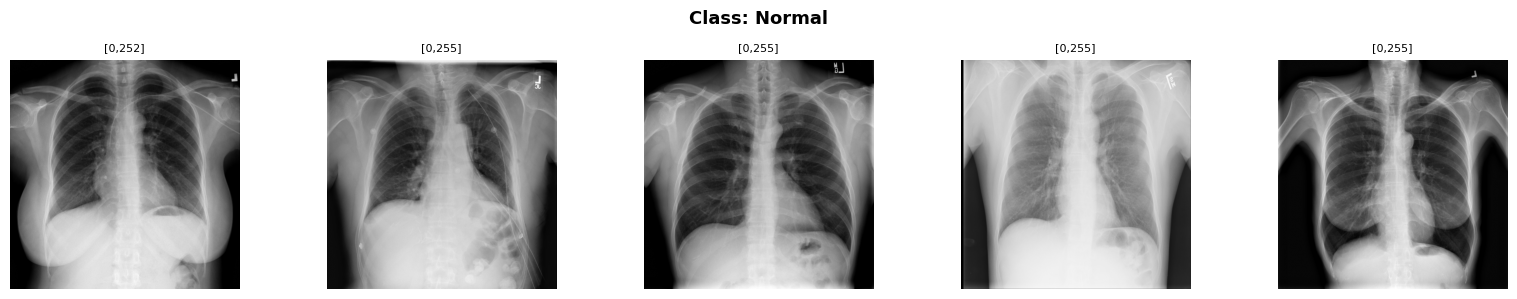

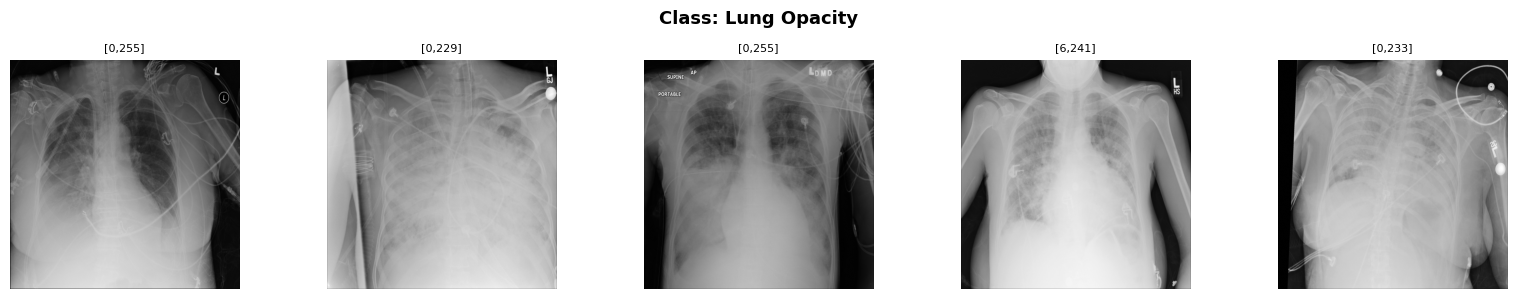

In [10]:
for c in class_info["class"].unique():
    ids = class_info[class_info["class"] == c].sample(5, random_state=42)["patientId"]
    fig, axes = plt.subplots(1, 5, figsize=(16, 3))
    fig.suptitle(f"Class: {c}", fontsize=13, fontweight="bold")

    for i, pid in enumerate(ids):
        img = pydicom.dcmread(os.path.join(image_dir, pid + ".dcm")).pixel_array
        axes[i].imshow(img, cmap="gray")
        axes[i].set_title(f"[{img.min()},{img.max()}]", fontsize=8)
        axes[i].axis("off")

    plt.tight_layout()
    plt.savefig(os.path.join(processed_dir, f"eda_samples_{c.replace('/', '_')}.png"), dpi=120)
    plt.show()

## 9 — EDA: Image Shape Check (500-patient sample)

In [11]:
shapes     = []
sample_ids = class_info["patientId"].sample(min(500, len(class_info)), random_state=42)

for pid in tqdm(sample_ids, desc="Checking shapes"):
    img = pydicom.dcmread(os.path.join(image_dir, pid + ".dcm")).pixel_array
    shapes.append(img.shape)

shape_counts = Counter(shapes)
print("Shape distribution:", shape_counts)
print(f"Unique shapes found: {len(shape_counts)}")
if len(shape_counts) == 1:
    print("✓ All images are the same shape.")

Checking shapes: 100%|██████████| 500/500 [00:03<00:00, 151.82it/s]

Shape distribution: Counter({(1024, 1024): 500})
Unique shapes found: 1
✓ All images are the same shape.


## 10 — EDA: Pixel Intensity Statistics

Image shape : (1024, 1024)
Dtype       : uint8
Min / Max   : 0 / 245
Mean / Std  : 120.19 / 73.87


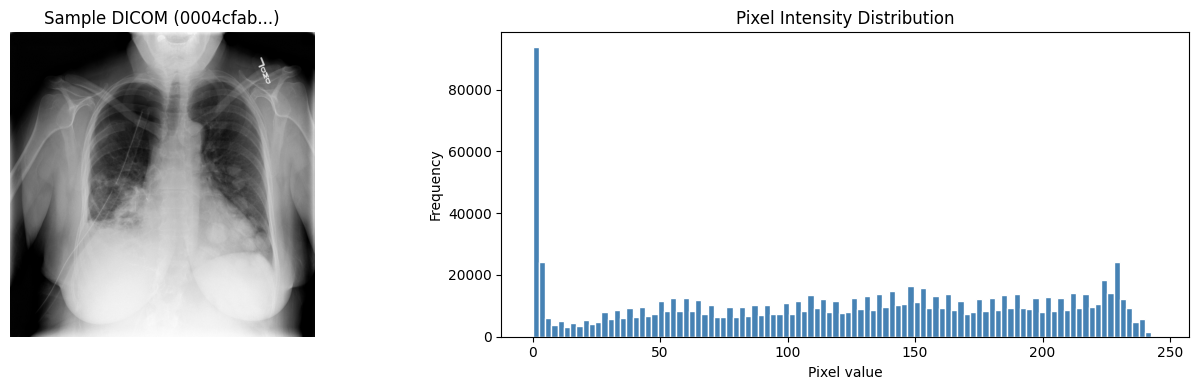

In [12]:
sample_pid = class_info.iloc[0]["patientId"]
sample_img = pydicom.dcmread(os.path.join(image_dir, sample_pid + ".dcm")).pixel_array

print(f"Image shape : {sample_img.shape}")
print(f"Dtype       : {sample_img.dtype}")
print(f"Min / Max   : {sample_img.min()} / {sample_img.max()}")
print(f"Mean / Std  : {sample_img.mean():.2f} / {sample_img.std():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].imshow(sample_img, cmap="gray")
axes[0].set_title(f"Sample DICOM ({sample_pid[:8]}...)")
axes[0].axis("off")

axes[1].hist(sample_img.flatten(), bins=100, color="steelblue", edgecolor="white")
axes[1].set_title("Pixel Intensity Distribution")
axes[1].set_xlabel("Pixel value")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig(os.path.join(processed_dir, "eda_pixel_distribution.png"), dpi=150)
plt.show()

## 11 — EDA: Bounding Box Overlay Visualisation

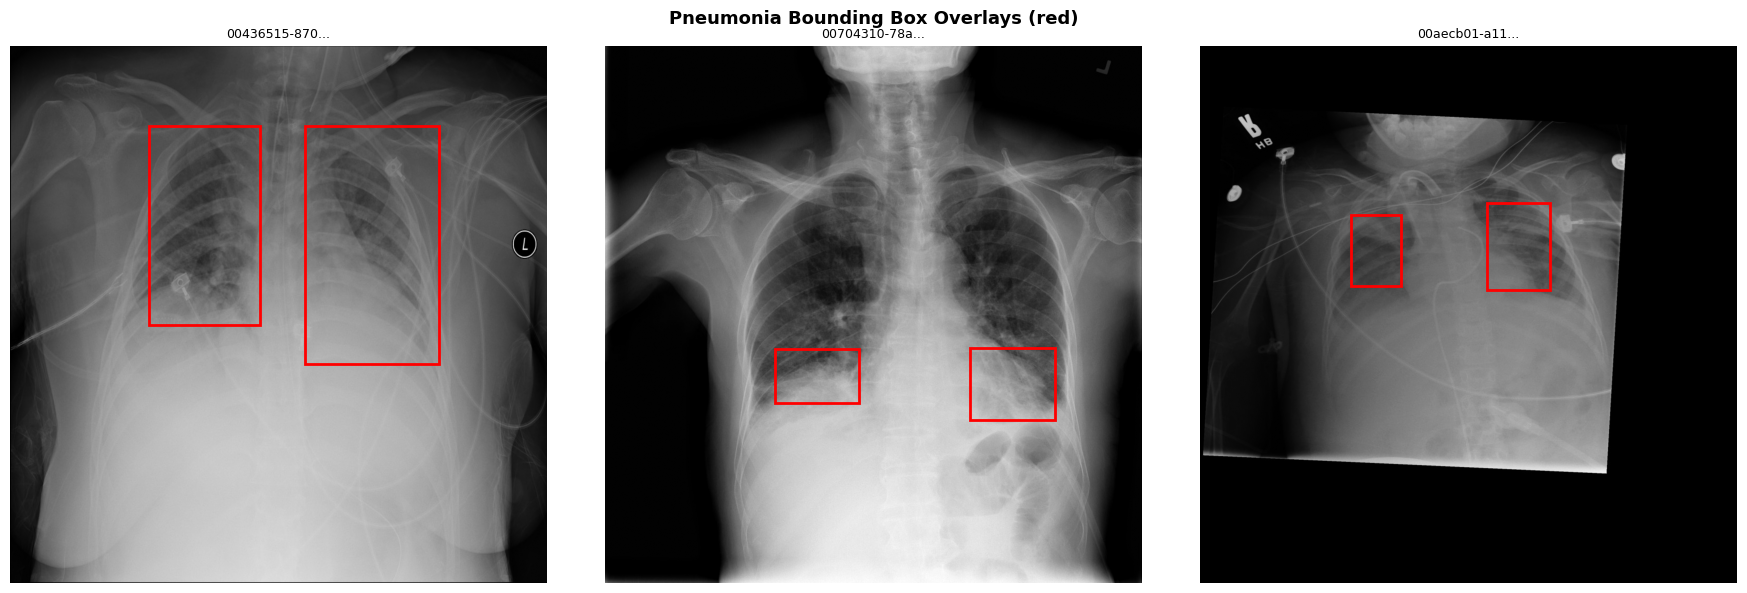

In [13]:
# Show first 3 positive patients with their bounding boxes overlaid
pos_pids = pneumonia_boxes["patientId"].unique()[:3]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, pid in zip(axes, pos_pids):
    img = pydicom.dcmread(os.path.join(image_dir, pid + ".dcm")).pixel_array
    ax.imshow(img, cmap="gray")
    for _, r in pneumonia_boxes[pneumonia_boxes["patientId"] == pid].iterrows():
        rect = plt.Rectangle(
            (r["x"], r["y"]), r["width"], r["height"],
            fill=False, color="red", linewidth=2
        )
        ax.add_patch(rect)
    ax.set_title(f"{pid[:12]}...", fontsize=9)
    ax.axis("off")

plt.suptitle("Pneumonia Bounding Box Overlays (red)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(processed_dir, "eda_bbox_overlays.png"), dpi=150)
plt.show()

## 12 — Binary Labels

> Three classes → binary: `Lung Opacity → 1`, everything else → 0.

Binary label distribution:
binary_label
0    20672
1     9555

Percentages:
binary_label
0    68.39
1    31.61

Class imbalance ratio : 2.16:1  (negative:positive)


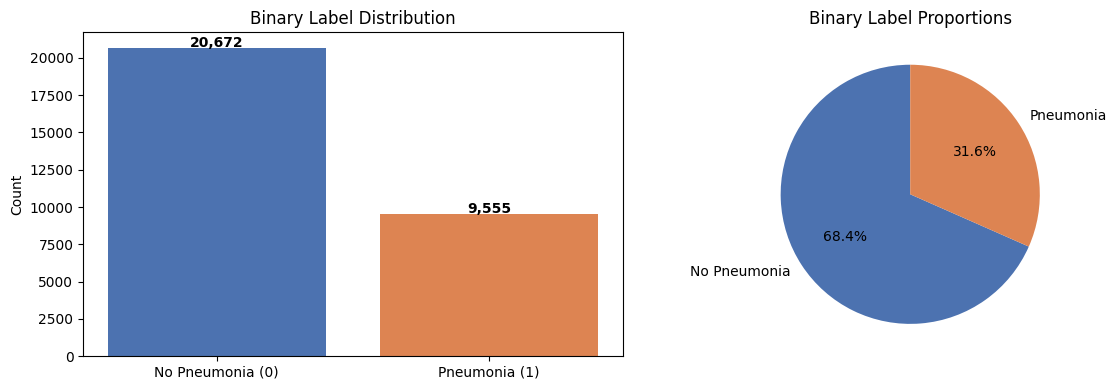

In [14]:
class_info["binary_label"] = (class_info["class"] == "Lung Opacity").astype(int)

counts    = class_info["binary_label"].value_counts()
pct       = class_info["binary_label"].value_counts(normalize=True) * 100
imbalance = counts[0] / counts[1]

print("Binary label distribution:")
print(counts.to_string())
print("\nPercentages:")
print(pct.round(2).to_string())
print(f"\nClass imbalance ratio : {imbalance:.2f}:1  (negative:positive)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(["No Pneumonia (0)", "Pneumonia (1)"], counts.values,
            color=["#4C72B0", "#DD8452"])
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f"{v:,}", ha="center", fontweight="bold")
axes[0].set_title("Binary Label Distribution")
axes[0].set_ylabel("Count")

axes[1].pie(counts.values, labels=["No Pneumonia", "Pneumonia"],
            autopct="%1.1f%%", colors=["#4C72B0", "#DD8452"], startangle=90)
axes[1].set_title("Binary Label Proportions")

plt.tight_layout()
plt.savefig(os.path.join(processed_dir, "eda_binary_labels.png"), dpi=150)
plt.show()

## 13 — Class Weights

> `pos_weight = neg / pos` for `BCEWithLogitsLoss`.
> **Note:** recomputed from train split only in Notebook 2 to avoid leakage.

In [15]:
classes          = np.array([0, 1])
weights          = compute_class_weight("balanced", classes=classes,
                                        y=class_info["binary_label"])
class_weight_dict = dict(zip(classes, weights))

neg_count        = (class_info["binary_label"] == 0).sum()
pos_count        = (class_info["binary_label"] == 1).sum()
pos_weight_value = neg_count / pos_count

print(f"Negative patients        : {neg_count:,}")
print(f"Positive patients        : {pos_count:,}")
print(f"sklearn class weights    : {class_weight_dict}")
print(f"pos_weight (BCELogits)   : {pos_weight_value:.4f}")
print("\n(This is a dataset-level estimate; Notebook 2 recomputes from train split only.)")

Negative patients        : 20,672
Positive patients        : 9,555
sklearn class weights    : {0: 0.731109713622291, 1: 1.5817373103087389}
pos_weight (BCELogits)   : 2.1635

(This is a dataset-level estimate; Notebook 2 recomputes from train split only.)


## 14 — Bounding Box Map

In [16]:
bbox_map = {}
for pid, group in labels[labels["Target"] == 1].groupby("patientId"):
    bbox_map[pid] = group[["x", "y", "width", "height"]].values

print(f"Patients with bounding boxes : {len(bbox_map)}")
print(f"Sample entry: {list(bbox_map.items())[0]}")

Patients with bounding boxes : 6012
Sample entry: ('000db696-cf54-4385-b10b-6b16fbb3f985', array([[316., 318., 170., 478.],
       [660., 375., 146., 402.]]))


## 15 — Stratified Train / Val / Test Split (70 / 15 / 15)

> Split on `patientId` — never on images — to prevent data leakage.

In [17]:
# One unique label per patient (drop any accidental duplicates before splitting)
class_info_dedup = class_info.drop_duplicates(subset="patientId").reset_index(drop=True)
patients         = class_info_dedup["patientId"].values
patient_labels   = class_info_dedup.set_index("patientId")["binary_label"]

train_ids, temp_ids = train_test_split(
    patients, test_size=0.30, random_state=42,
    stratify=patient_labels[patients]
)
val_ids, test_ids = train_test_split(
    temp_ids, test_size=0.50, random_state=42,
    stratify=patient_labels[temp_ids]
)

print(f"Total unique patients : {len(patients):,}")
print(f"Train                 : {len(train_ids):,}")
print(f"Val                   : {len(val_ids):,}")
print(f"Test                  : {len(test_ids):,}")
print(f"Sum check             : {len(train_ids)+len(val_ids)+len(test_ids):,}")

print()
for name, ids in [("Train", train_ids), ("Val", val_ids), ("Test", test_ids)]:
    pos = patient_labels[ids].sum()
    pct = pos / len(ids) * 100
    print(f"{name:5s}  positive rate : {pos}/{len(ids)}  ({pct:.1f}%)")

Total unique patients : 26,684
Train                 : 18,678
Val                   : 4,003
Test                  : 4,003
Sum check             : 26,684

Train  positive rate : 4208/18678  (22.5%)
Val    positive rate : 902/4003  (22.5%)
Test   positive rate : 902/4003  (22.5%)


## 16 — Preprocessing Functions

### Design decisions
- **Z-score** instead of max-scaling: preserves relative contrast between patients
- **3-channel stack**: pretrained CNNs (DenseNet, EfficientNet) expect RGB input
- **ROI crop**: bounding-box crop for positive patients, padded by 10 px

In [18]:
def normalize(img: np.ndarray) -> np.ndarray:
    """Z-score normalise. Epsilon avoids division-by-zero on flat images."""
    return (img - img.mean()) / (img.std() + 1e-8)


def preprocess_full(path: str, size: tuple = (224, 224)) -> np.ndarray:
    """
    DICOM → float32 → resize 224×224 → Z-score → 3-channel.
    Saved as <pid>_full.npy.
    """
    img = pydicom.dcmread(path).pixel_array.astype(np.float32)
    img = cv2.resize(img, size)
    img = normalize(img)
    img = np.stack([img] * 3, axis=-1)
    return img.astype(np.float32)


def preprocess_roi(path: str, pid: str, size: tuple = (224, 224)) -> np.ndarray:
    """
    Crop union of all bounding boxes (+10 px padding) → resize → Z-score → 3-channel.
    Saved as <pid>_roi.npy. Only called for positive patients in bbox_map.
    """
    img   = pydicom.dcmread(path).pixel_array.astype(np.float32)
    boxes = bbox_map[pid]

    x_min = int(min(b[0]        for b in boxes))
    y_min = int(min(b[1]        for b in boxes))
    x_max = int(max(b[0] + b[2] for b in boxes))
    y_max = int(max(b[1] + b[3] for b in boxes))

    pad   = 10
    x_min = max(0,            x_min - pad)
    y_min = max(0,            y_min - pad)
    x_max = min(img.shape[1], x_max + pad)
    y_max = min(img.shape[0], y_max + pad)

    img = img[y_min:y_max, x_min:x_max]
    img = cv2.resize(img, size)
    img = normalize(img)
    img = np.stack([img] * 3, axis=-1)
    return img.astype(np.float32)


print("Preprocessing functions defined.")

Preprocessing functions defined.


## 17 — Save All Preprocessed Images

In [19]:
failed = []

for pid in tqdm(class_info_dedup["patientId"], desc="Preprocessing"):
    dcm_path = os.path.join(image_dir,     pid + ".dcm")
    full_out = os.path.join(processed_dir, pid + "_full.npy")
    roi_out  = os.path.join(processed_dir, pid + "_roi.npy")

    try:
        if not os.path.exists(full_out):
            np.save(full_out, preprocess_full(dcm_path))

        if pid in bbox_map and not os.path.exists(roi_out):
            np.save(roi_out, preprocess_roi(dcm_path, pid))

    except Exception as e:
        failed.append((pid, str(e)))

if failed:
    print(f"\n{len(failed)} files failed:")
    for pid, err in failed[:10]:
        print(f"  {pid}: {err}")
else:
    print("\n✓ All images saved successfully.")

Preprocessing: 100%|██████████| 26684/26684 [06:00<00:00, 74.11it/s]


✓ All images saved successfully.


## 18 — Save Labels, Splits & XAI Examples

In [20]:
# Single source of truth for all notebooks
class_info_dedup.to_csv(os.path.join(processed_dir, "labels.csv"), index=False)

pd.Series(train_ids).to_csv(os.path.join(processed_dir, "train_ids.csv"), index=False)
pd.Series(val_ids  ).to_csv(os.path.join(processed_dir, "val_ids.csv"),   index=False)
pd.Series(test_ids ).to_csv(os.path.join(processed_dir, "test_ids.csv"),  index=False)

# XAI examples — 10 positive + 10 negative from TEST SET ONLY (held-out)
test_df = class_info_dedup[class_info_dedup["patientId"].isin(test_ids)]
xai_pos = test_df[test_df["binary_label"] == 1].sample(10, random_state=42)["patientId"]
xai_neg = test_df[test_df["binary_label"] == 0].sample(10, random_state=42)["patientId"]
xai_ids = pd.concat([xai_pos, xai_neg]).reset_index(drop=True)
xai_ids.to_csv(os.path.join(processed_dir, "xai_examples.csv"), index=False)

print("All CSVs saved:")
print(f"  labels.csv          — {len(class_info_dedup):,} rows")
print(f"  train_ids.csv       — {len(train_ids):,} patients")
print(f"  val_ids.csv         — {len(val_ids):,} patients")
print(f"  test_ids.csv        — {len(test_ids):,} patients")
print(f"  xai_examples.csv    — {len(xai_ids)} patients (10 pos + 10 neg)")

All CSVs saved:
  labels.csv          — 26,684 rows
  train_ids.csv       — 18,678 patients
  val_ids.csv         — 4,003 patients
  test_ids.csv        — 4,003 patients
  xai_examples.csv    — 20 patients (10 pos + 10 neg)


## 19 — Pipeline Summary

In [21]:
print("=" * 55)
print("           PREPROCESSING PIPELINE SUMMARY")
print("=" * 55)
print(f"Total patients    : {len(class_info_dedup):,}")
print(f"Train             : {len(train_ids):,}")
print(f"Validation        : {len(val_ids):,}")
print(f"Test              : {len(test_ids):,}")
print(f"Positive patients : {(class_info_dedup['binary_label']==1).sum():,}  "
      f"({(class_info_dedup['binary_label']==1).mean()*100:.1f}%)")
print(f"pos_weight (BCE)  : {pos_weight_value:.4f}")
print(f"Saved to          : {processed_dir}")
print("=" * 55)
print("\n Notebook 1 complete. Run Notebook 2 next.")

           PREPROCESSING PIPELINE SUMMARY
Total patients    : 26,684
Train             : 18,678
Validation        : 4,003
Test              : 4,003
Positive patients : 6,012  (22.5%)
pos_weight (BCE)  : 2.1635
Saved to          : D:\XAI_project\processed

 Notebook 1 complete. Run Notebook 2 next.
